# Flip-Chip Devices in Quantum Metal

This notebook builds a qubit–resonator pair in a flip-chip stack and then analyzes it with the energy-participation-ratio (EPR) method.

The stack has two chips facing each other a few micrometers apart. Here the readout resonator sits on the bottom chip, called the control chip (`C_chip`), and the qubit on the top chip, the qubit chip (`Q_chip`); other layouts put both on one chip or split them differently.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/docs/tut/2-From-components-to-chip/FlipChip-design-tutorial.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=docs%2Ftut%2F2-From-components-to-chip%2FFlipChip-design-tutorial.ipynb)

In [2]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

> 💡 **Desktop GUI or inline.** `metal.gui(design)` opens the desktop `MetalGUI` when Qt and a display are available and falls back to an inline viewer (Colab, Binder, a server) with the same API, so `gui.rebuild()` and `gui.screenshot()` work in both. See [1.1 Quick start](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.1-Quick-start.html) and [`docs/headless-usage.rst`](https://qiskit-community.github.io/qiskit-metal/headless-usage.html).
>
> Section 1 (the layout) runs anywhere. Sections 2 and 3 add a material to Ansys and run an HFSS eigenmode simulation with EPR analysis; they need Ansys HFSS with pyEPR on Windows, and the cells that talk to Ansys are shown here without outputs.

> 🧭 **Other simulation pathways.** This notebook uses Ansys, which needs a license. Without one, the same kind of result can come from the open-source ElmerFEM path for capacitance (tutorial 4.19) or the pip-installable gmsh + scikit-fem solver for eigenmodes, couplings and capacitance (tutorials 4.43–4.45); AWS Palace is available through SQDMetal, with a native integration in progress. [Simulation pathways](https://qiskit-community.github.io/qiskit-metal/simulation-pathways.html) summarizes what each solver computes, how to install it, and which tutorials use it.

## 1. Building a flip-chip design

`DesignFlipChip` works like `DesignPlanar`, except that it has two chips and each component says which one it is drawn on with its `chip` option. The two chips are called `C_chip` and `Q_chip`.

In [3]:
import qiskit_metal as metal
from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.resonators.readoutres_fc import ReadoutResFC

In [4]:
design = designs.DesignFlipChip()
design.metadata["design_name"] = "FlipChip_Device"
# Allow re-running a cell to overwrite components with the same name
design.overwrite_enabled = True

gui = metal.gui(design)

Next, we draw an Xmon on the Q-chip, and a readout resonator on the C-chip.

In [5]:
# delete existing components
design.delete_all_components()

# Draw an Xmon on the Q_chip: the `chip` option selects the chip.
options_cpads = Dict(
    connector_type="0",  # claw type
    claw_length="30um",
    ground_spacing="5um",
    claw_width="10um",
    claw_gap="6um",
)
options = Dict(
    chip="Q_chip",
    cross_width="20um",
    cross_length="150um",
    cross_gap="20um",
    connection_pads=Dict(claw_west=Dict(connector_location="180", **options_cpads)),
)

# position the center of the Xmon at (0,0)
q1_x = "0.0 mm"
q1_y = "0.0 mm"

# build the device, positioned at (q1_x, q1_y)
q1 = TransmonCross(design, "Q1", options=Dict(pos_x=q1_x, pos_y=q1_y, **options))

# rebuild in gui
gui.rebuild()
gui.autoscale()

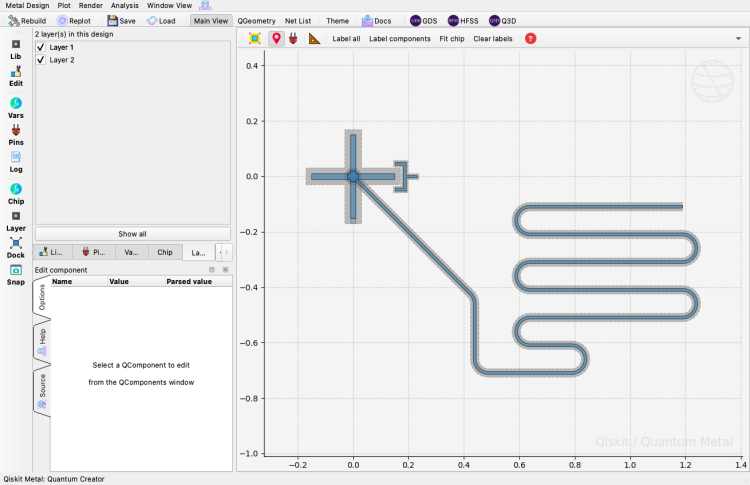

In [6]:
# Draw a readout resonator on the C_chip (chip='C_chip').
# The resonator can have any shape; this one is a lambda/4 CPW resonator.
# The open-ended end of the resonator has a circular shape with a radius of readout_radius. Change this radius to change the qubit-resonator coupling strength.
# The cpw_width and cpw_gap are the size of the signal line and the ground gap of the cpw transmission line.
# The parameters readout_l1 ... l5, are the lengths of various parts of the cpw.
# arc_step is the length of a line that approximates an arc.
options = Dict(
    chip="C_chip",
    readout_radius="20 um",
    readout_cpw_width="10 um",
    readout_cpw_gap="10 um",
    readout_cpw_turnradius="50 um",
    readout_l1="600 um",
    readout_l2="200 um",
    readout_l3="300 um",
    readout_l4="150 um",
    readout_l5="550 um",
    arc_step="5 um",
)

# the resonator is set to have its origin at the center of the circular patch.
# So we set the qubit and the resonator to share the same coordinate (q1_x, q1_y)
r1 = ReadoutResFC(design, "R1", options=Dict(pos_x=q1_x, pos_y=q1_y, **options))

# rebuild in gui
gui.rebuild()
gui.autoscale()
gui.screenshot()

## 2. Preparation before rendering in Ansys

As described before, we have specified two chips in the <code>FlipChipDesign</code> class, i.e. C_chip and Q_chip. This information is stored in the chips variables. 

In [7]:
design.chips

{'C_chip': {'material': 'silicon',
  'layer_start': '0',
  'layer_end': '2048',
  'size': {'center_x': '0.0mm',
   'center_y': '0.0mm',
   'center_z': '0.0mm',
   'size_x': '9mm',
   'size_y': '9mm',
   'size_z': '-280um',
   'sample_holder_top': '890um',
   'sample_holder_bottom': '1650um'}},
 'Q_chip': {'material': 'silicon',
  'layer_start': '0',
  'layer_end': '2048',
  'size': {'center_x': '0.0mm',
   'center_y': '0.0mm',
   'center_z': '20 um',
   'size_x': '9mm',
   'size_y': '9mm',
   'size_z': '280um',
   'sample_holder_top': '890um',
   'sample_holder_bottom': '1650um'}}}

It is important to note that in terms of component rendering in ANSYS, the components are drawn on an XY plane with its Z-coordinate being defined by 'center_z'. For the design object we just created, C_chip components are drawn at z=0, and the Q_chip components are drawn at 20 um.

In [8]:
design.chips["C_chip"]["size"]["center_z"]

'0.0mm'

In [9]:
design.chips["Q_chip"]["size"]["center_z"]

'20 um'

Next, we set the Q_chip to be at a distance of, say 10 um, from the C_chip.

In [10]:
design.chips["Q_chip"]["size"]["center_z"] = "10 um"
design.chips["Q_chip"]["size"]["center_z"]

'10 um'

You may want a different substrate material. Rather than modifying an existing material, define a new one in the Ansys material library. If you don't need this, skip to the next section.

For example, silicon with a dielectric constant of 11.45 instead of the default 11.9, called `Si_11.45`. First add it to the Ansys material library (by hand, or with the script below, which needs a running Ansys HFSS), then assign it to the chips in the design.

In [11]:
# new material properties
newMaterial_name = "Si_11.45"
newMaterial_permittivity = "11.45"
newMaterial_losstangent = "1e-7"

In [ ]:
# Add the new material to the open Ansys project (needs Ansys HFSS).
from pyEPR import ansys, project_info

# get the handles to the ANSYS system
ans_prj = project_info.ProjectInfo()
oProject = ans_prj.project._project
defmanager = oProject.GetDefinitionManager()
# check if the material exists
if not defmanager.DoesMaterialExist(newMaterial_name):
    defmanager.AddMaterial(
        [
            "NAME:%s" % (newMaterial_name),
            "CoordinateSystemType:=",
            "Cartesian",
            "BulkOrSurfaceType:=",
            1,
            ["NAME:PhysicsTypes", "set:=", ["Electromagnetic"]],
            "permittivity:=",
            "%s" % (newMaterial_permittivity),
            "dielectric_loss_tangent:=",
            "%s" % (newMaterial_losstangent),
        ]
    )
# release the handle to ANSYS
ans_prj.project.release()
ans_prj.desktop.release()
ans_prj.app.release()
ansys.release()

In [12]:
# Specify the new material assignment for the chip
design.chips["C_chip"]["material"] = newMaterial_name
design.chips["Q_chip"]["material"] = newMaterial_name

## 3. Run EPR analysis

The EPR analysis follows tutorial [4.02 Eigenmode and EPR](../4-Analysis/4.02-Eigenmode-and-EPR.ipynb). First create an `EPRanalysis` object and update the HFSS simulation setup; this part runs without Ansys.

In [13]:
from qiskit_metal.analyses.quantization import EPRanalysis

eig_fc = EPRanalysis(design, "hfss")
eig_fc.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1,
 'n_modes': 1,
 'max_delta_f': 0.5,
 'max_passes': 10,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'}}

In [14]:
# update setup setting
eig_fc.sim.setup.max_passes = 20
eig_fc.sim.setup.vars.Lj = "10 nH"
# since we are analysing both the qubit and the resonator, we set the number of modes to be 2
eig_fc.sim.setup.n_modes = 2
# if there is not enough computational power, you can set a less stringent max_delta_f
eig_fc.sim.setup.max_delta_f = 1
eig_fc.sim.setup.min_freq_ghz = 1.5
# pass the name of the junction (for the EPR analysis purpose)
eig_fc.setup.junctions.jj.rect = "JJ_rect_Lj_Q1_rect_jj"
eig_fc.setup.junctions.jj.line = "JJ_Lj_Q1_rect_jj_"

eig_fc.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1.5,
 'n_modes': 2,
 'max_delta_f': 1,
 'max_passes': 20,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'}}

Then run the HFSS simulation and the EPR analysis. These cells need Ansys HFSS and are shown without outputs.

In [ ]:
eig_fc.sim.run(
    name="qubitres", components=["Q1", "R1"], open_terminations=[], box_plus_buffer=True
)

In [ ]:
eig_fc.setup.dissipatives.dielectrics_bulk = ["Q_chip", "C_chip"]
eig_fc.run_epr()

In [ ]:
eig_fc.sim.close()